## Kidneys
Finding the kidneys in computed tomography scans

As part of a diagnostic system, we need to locate the kidneys in computed tomography scans. We have been provided with an example DICOM slice (1-189.dcm) that we can use to develop our algorithm.

 

We start by reading the scan slice and create a first binary estimate by applying a lower threshold of 100 and a high threshold of 250. Meaning that pixels with a value that is within these limits are set to foreground (1) and the rest to background (0). This results in a binary image with several structures.

 

We do a BLOB analysis of the binary image and computes the area and perimeter of all BLOBS. The kidneys are identified by filtering the BLOBS using the area and the perimeter.

 

After the filtering, where only the two kidneys are left a morphological closing with a disk-shaped structuring element (radius=3) is performed on the binary image.

 

Start by answering the question about the BLOB area estimation.

 

In [ ]:
import pydicom as dicom
import numpy as np
from scipy.ndimage import label
from skimage.measure import regionprops
from skimage.morphology import closing, disk
import matplotlib.pyplot as plt

In [ ]:
in_dir = "kidneys/"
im_name = "1-189.dcm"
ds = dicom.dcmread(in_dir + im_name)
print(ds)

In [ ]:
img = ds.pixel_array
low_threshold = 100
high_threshold = 250
binary_img = (img >= low_threshold) & (img <= high_threshold).astype(np.uint8)

In [ ]:
# Step 3: BLOB analysis
labeled_img, num_blobs = label(binary_img)
props = regionprops(labeled_img)

# Compute area and perimeter for each BLOB
blobs = []
for prop in props:
    area = prop.area  # Area in pixels
    perimeter = prop.perimeter  # Perimeter in pixels
    blobs.append(
        {
            "label": prop.label,
            "area": area,
            "perimeter": perimeter,
            "centroid": prop.centroid,
        }
    )

# Step 4: Filter BLOBs to identify kidneys
# Assumption: Kidneys are among the largest BLOBs, roughly symmetric
# Sort BLOBs by area (descending)
blobs_sorted = sorted(blobs, key=lambda x: x["area"], reverse=True)

# Heuristic: Select top 2 BLOBs with similar areas (e.g., within 50% of each other)
# Example criteria (adjust based on data):
min_area = 500  # Minimum area in pixels (tune based on resolution)
max_area = 5000  # Maximum area in pixels
kidney_blobs = []
for blob in blobs_sorted:
    if min_area <= blob["area"] <= max_area:
        kidney_blobs.append(blob)
    if len(kidney_blobs) == 2:
        # Check if areas are reasonably similar
        area1, area2 = kidney_blobs[0]["area"], kidney_blobs[1]["area"]
        if abs(area1 - area2) / max(area1, area2) < 0.5:
            break
        else:
            kidney_blobs.pop()  # Remove if not similar

if len(kidney_blobs) != 2:
    print("Warning: Could not identify exactly two kidneys.")

# Create binary image with only kidney BLOBs
kidney_mask = np.zeros_like(binary_img)
for blob in kidney_blobs:
    kidney_mask[labeled_img == blob["label"]] = 1

# Step 5: Morphological closing
structuring_element = disk(3)  # Disk with radius 3
closed_img = closing(kidney_mask, structuring_element)

# Optional: Visualize results
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.title("Original Binary Image")
plt.imshow(binary_img, cmap="gray")
plt.subplot(132)
plt.title("Kidney BLOBs")
plt.imshow(kidney_mask, cmap="gray")
plt.subplot(133)
plt.title("After Morphological Closing")
plt.imshow(closed_img, cmap="gray")
plt.tight_layout()
plt.show()

# Optional: Save or return the final kidney mask
# np.save("kidney_mask.npy", closed_img)

In [ ]:
total_area = kidney_blobs[0]["area"] + kidney_blobs[1]["area"]
total_area * 0.78 * 0.78

## Hounsfield

In [ ]:
import pydicom as dicom
import numpy as np

# Step 1: Read DICOM file
in_dir = "kidneys/"
im_name = "1-189.dcm"
ds = dicom.dcmread(in_dir + im_name)

# Extract pixel array
img = ds.pixel_array

# Convert to Hounsfield Units (HU) if necessary
try:
    rescale_slope = ds.RescaleSlope
    rescale_intercept = ds.RescaleIntercept
    img_hu = img * rescale_slope + rescale_intercept
except AttributeError:
    print("Warning: RescaleSlope/Intercept not found. Assuming pixel_array is in HU.")
    img_hu = img


# Step 3: Compute median Hounsfield Unit for kidney pixels
kidney_pixels = img_hu[closed_img == 1]
if kidney_pixels.size > 0:
    median_hu = np.median(kidney_pixels)
    print(f"Median Hounsfield Unit for the kidneys: {median_hu:.2f} HU")
else:
    print("Error: No kidney pixels found in the mask.")

## Dice score

In [ ]:
import skimage.io as io
from scipy.spatial import distance

In [ ]:
ground_truth_img = io.imread(in_dir + "kidneys_gt.png")
gt_bin = ground_truth_img > 0
dice_score = 1 - distance.dice(closed_img.ravel(), gt_bin.ravel())
print(f"DICE score {dice_score}")

In [ ]:
# Step 3: BLOB analysis
labeled_img, num_blobs = label(binary_img)
props = regionprops(labeled_img)

# Compute area and perimeter for each BLOB
blobs = []
for prop in props:
    area = prop.area  # Area in pixels
    perimeter = prop.perimeter  # Perimeter in pixels
    blobs.append(
        {
            "label": prop.label,
            "area": area,
            "perimeter": perimeter,
            "centroid": prop.centroid,
        }
    )

# Step 4: Filter BLOBs to identify kidneys
# Assumption: Kidneys are among the largest BLOBs, roughly symmetric
# Sort BLOBs by area (descending)
blobs_sorted = sorted(blobs, key=lambda x: x["area"], reverse=True)
min_perimeter = 400
max_perimeter = 600
# Heuristic: Select top 2 BLOBs with similar areas (e.g., within 50% of each other)
# Example criteria (adjust based on data):
min_area = 500  # Minimum area in pixels (tune based on resolution)
max_area = 5000  # Maximum area in pixels
kidney_blobs = []
for blob in blobs_sorted:
    if min_area <= blob["area"] <= max_area and min_perimeter <= blob["perimeter"] <= max_perimeter:
        kidney_blobs.append(blob)
    if len(kidney_blobs) == 2:
        # Check if areas are reasonably similar
        area1, area2 = kidney_blobs[0]["area"], kidney_blobs[1]["area"]
        if abs(area1 - area2) / max(area1, area2) < 0.5:
            break
        else:
            kidney_blobs.pop()  # Remove if not similar

if len(kidney_blobs) != 2:
    print("Warning: Could not identify exactly two kidneys.")

# Create binary image with only kidney BLOBs
kidney_mask = np.zeros_like(binary_img)
for blob in kidney_blobs:
    kidney_mask[labeled_img == blob["label"]] = 1

# Step 5: Morphological closing
structuring_element = disk(3)  # Disk with radius 3
closed_img = closing(kidney_mask, structuring_element)

# Optional: Visualize results
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.title("Original Binary Image")
plt.imshow(binary_img, cmap="gray")
plt.subplot(132)
plt.title("Kidney BLOBs")
plt.imshow(kidney_mask, cmap="gray")
plt.subplot(133)
plt.title("After Morphological Closing")
plt.imshow(closed_img, cmap="gray")
plt.tight_layout()
plt.show()

# Optional: Save or return the final kidney mask
# np.save("kidney_mask.npy", closed_img)

# Page 2

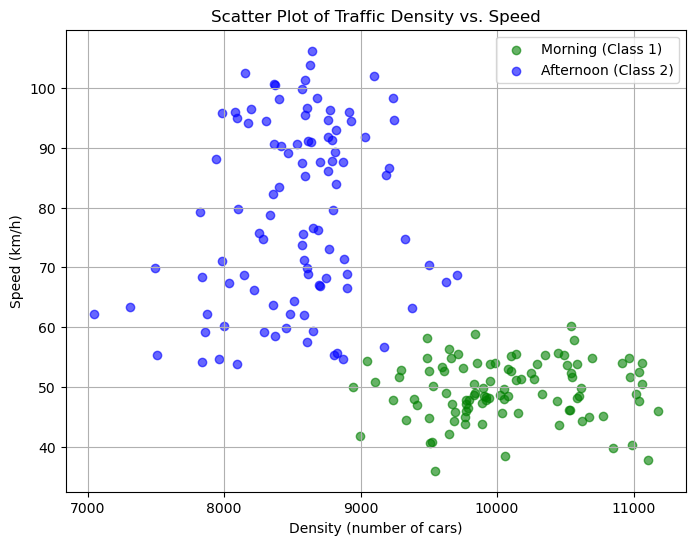

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the training dataset
# Assuming traffic_train.txt is a space-separated or comma-separated file with columns: density, speed, weather
train_data = pd.read_csv(
    "traffic/traffic_train.txt", header=None, names=["density", "speed", "weather"]
)

# Step 2: Extract first 100 samples for each class
# Morning traffic: rows 0–99 (1–100 in 1-based indexing)
morning = train_data.iloc[0:100]
# Afternoon traffic: rows 140–239 (141–240 in 1-based indexing)
afternoon = train_data.iloc[140:240]

# Step 3: Create scatter plot
plt.figure(figsize=(8, 6))
# Plot morning traffic (Class 1) as green dots
plt.scatter(
    morning["density"],
    morning["speed"],
    color="green",
    label="Morning (Class 1)",
    alpha=0.6,
)
# Plot afternoon traffic (Class 2) as blue dots
plt.scatter(
    afternoon["density"],
    afternoon["speed"],
    color="blue",
    label="Afternoon (Class 2)",
    alpha=0.6,
)

# Step 4: Customize plot
plt.xlabel("Density (number of cars)")
plt.ylabel("Speed (km/h)")
plt.title("Scatter Plot of Traffic Density vs. Speed")
plt.legend()
plt.grid(True)

# Step 5: Show plot
plt.show()

In [45]:
X_train = train_data[["density", "speed"]].values
y_train = np.array([1] * 140 + [2] * 140)
test_data = pd.read_csv(
    "traffic/traffic_test.txt", header=None, names=["density", "speed", "weather"]
)
X_test = test_data[["density", "speed"]].values
# Morning (Class 1: rows 0–59), Afternoon (Class 2: rows 60–119)
y_test = np.array([1] * 60 + [2] * 60)

In [49]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [50]:
# Step 3: Train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Step 4: Predict on test set
y_pred = lda.predict(X_test)

In [51]:
# Step 5: Count afternoon samples classified as morning
# Afternoon samples are rows 60–119 (indices 60–119 in 0-based indexing)
afternoon_indices = range(60, 120)
afternoon_predictions = y_pred[afternoon_indices]
# Count how many afternoon samples (true label = 2) are classified as morning (predicted label = 1)
misclassified_as_morning = np.sum(afternoon_predictions == 1)

print(
    f"Number of afternoon samples classified as morning samples (indicating traffic jams): {misclassified_as_morning}"
)

Number of afternoon samples classified as morning samples (indicating traffic jams): 9


In [56]:
morning = train_data.iloc[0:140]
morning[morning.weather == 1].count()

density    70
speed      70
weather    70
dtype: int64

# Page 3
Cell analysis

A laboratory has collected two grey-scale images of tissue samples showing a Nissl stain of cell nuclei appearing as bright spots in the images. The laboratory has asked you for help to do different types of analysis of their cell images.

 

There are two images: 

x_NisslStain_9-260.81.png

y_NisslStain_9-260.81.png

 

 

An expert has manually identified five corresponding landmarks in the two images. This provides us with two images where the landmarks are pixels with values 1 to 5. The rest of the pixels are 0. 

You should find the (x, y) positions of the landmarks in the two images. The result should be two lists of corresponding landmarks. The two images are called:

 

LabelsFixedImg.png

LabelsMovingImg.png

 

All data for the exam can be downloaded here.

 


You have decided first applying a few pre-processing steps to identify cell nuclei as individual binary objects. You do this by a BLOB analysis on the two images:

 

x_NisslStain_9-260.81.png

y_NisslStain_9-260.81.png

 

The images can be made into binary images by setting of threshold of 30 and cleaned by applying a morphological opening with a disk-sized structuring element of size 3. How many individual cells do you find in the two images after the BLOB analysis (without removing BLOBS touching the image border).

In [73]:
in_dir = "cells/"
fixed_img = io.imread(in_dir + "LabelsFixedImg.png")
moving_img = io.imread(in_dir + "LabelsMovingImg.png")
fixed_landmarks = []
moving_landmarks = []

# Find (x, y) coordinates for landmarks 1 to 5
for label in range(1, 6):
    # Fixed image
    y_fixed, x_fixed = np.where(fixed_img == label)
    if len(x_fixed) == 1:  # Expect exactly one pixel per landmark
        fixed_landmarks.append((x_fixed[0], y_fixed[0]))
    else:
        print(f"Warning: Landmark {label} in LabelsFixedImg has {len(x_fixed)} pixels")

    # Moving image
    y_moving, x_moving = np.where(moving_img == label)
    if len(x_moving) == 1:
        moving_landmarks.append((x_moving[0], y_moving[0]))
    else:
        print(
            f"Warning: Landmark {label} in LabelsMovingImg has {len(x_moving)} pixels"
        )
print("Fixed Image Landmarks (LabelsFixedImg.png):", fixed_landmarks)
print("Moving Image Landmarks (LabelsMovingImg.png):", moving_landmarks)
# Compute average landmark for each image
fixed_avg = np.mean(fixed_landmarks, axis=0)
moving_avg = np.mean(moving_landmarks, axis=0)

# Compute Euclidean distance between the two average landmarks
avg_distance = np.linalg.norm(np.array(fixed_avg) - np.array(moving_avg))
print(f"Euclidean distance between average landmarks: {avg_distance:.2f}")

Fixed Image Landmarks (LabelsFixedImg.png): [(np.int64(35), np.int64(107)), (np.int64(38), np.int64(73)), (np.int64(27), np.int64(31)), (np.int64(64), np.int64(52)), (np.int64(83), np.int64(50))]
Moving Image Landmarks (LabelsMovingImg.png): [(np.int64(2), np.int64(104)), (np.int64(21), np.int64(55)), (np.int64(44), np.int64(11)), (np.int64(74), np.int64(54)), (np.int64(96), np.int64(54))]
Euclidean distance between average landmarks: 7.28


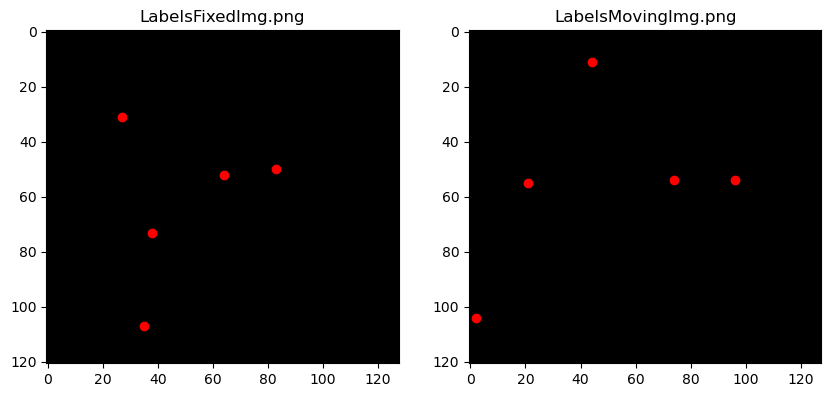

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(fixed_img, cmap="gray")
for x, y in fixed_landmarks:
    plt.plot(x, y, "ro")  # Red dots for landmarks
plt.title("LabelsFixedImg.png")
plt.subplot(122)
plt.imshow(moving_img, cmap="gray")
for x, y in moving_landmarks:
    plt.plot(x, y, "ro")
plt.title("LabelsMovingImg.png")
plt.show()

In [70]:
from skimage.morphology import opening, disk
from scipy.ndimage import label

In [71]:
# Function to process one image and count BLOBs
def count_cell_nuclei(image_path, threshold=30, disk_radius=3):
    # Load image
    img = io.imread(image_path)

    # Ensure image is grayscale (if RGB, convert to grayscale)
    if len(img.shape) == 3:
        img = img.mean(axis=2).astype(img.dtype)

    # Step 1: Thresholding
    binary_img = (img >= threshold).astype(np.uint8)

    # Step 2: Morphological opening
    structuring_element = disk(disk_radius)
    cleaned_img = opening(binary_img, structuring_element)

    # Step 3: BLOB analysis
    labeled_img, num_blobs = label(
        cleaned_img, structure=np.ones((3, 3))
    )  # 8-connectivity

    return num_blobs

In [72]:
x_blobs = count_cell_nuclei("cells/x_NisslStain_9-260.81.png")
y_blobs = count_cell_nuclei("cells/y_NisslStain_9-260.81.png")

# Print results
print(f"Number of cell nuclei in x_NisslStain_9-260.81.png: {x_blobs}")
print(f"Number of cell nuclei in y_NisslStain_9-260.81.png: {y_blobs}")

Number of cell nuclei in x_NisslStain_9-260.81.png: 12
Number of cell nuclei in y_NisslStain_9-260.81.png: 12


# Page 4

In [77]:
from sklearn.decomposition import PCA
import os

In [78]:
def load_images(image_dir, image_names, target_size=None):
    images = []
    for name in image_names:
        img = io.imread(os.path.join(image_dir, name))
        # Convert to grayscale if RGB
        if len(img.shape) == 3:
            img = img.mean(axis=2).astype(img.dtype)
        # Resize if specified
        if target_size:
            from skimage.transform import resize

            img = resize(img, target_size, anti_aliasing=True)
        # Flatten image to 1D vector
        img_flat = img.flatten()
        images.append(img_flat)
    return np.array(images)

In [80]:
# Directory containing images (update with your path)
image_dir = "screws/"  # Replace with your directory
image_names = [
    f"screws_{i:03d}.jpg" for i in range(0, 20)
]  # screws_001.jpg to screws_020.jpg

# Load images (assuming all have same dimensions, e.g., 100x100)
# If dimensions vary, set target_size=(100, 100)
images = load_images(image_dir, image_names)

# Step 2: Compute average image
mean_image = np.mean(images, axis=0)

# Step 3: Center the data (subtract mean)
centered_images = images - mean_image

# Step 4: Apply PCA to get 7 principal components
pca = PCA(n_components=7)
pca.fit(centered_images)

# Step 5: Project images into PCA space
pca_coordinates = pca.transform(centered_images)

In [82]:
coord_007 = pca_coordinates[6]
coord_008 = pca_coordinates[7]
np.linalg.norm(coord_007 - coord_008)

np.float64(8796.403045268384)

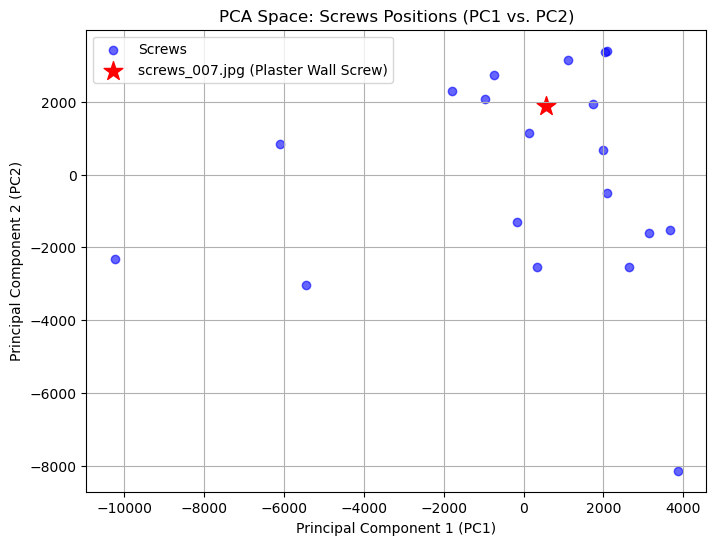

In [83]:
plt.figure(figsize=(8, 6))
# Plot all screws as blue dots
plt.scatter(pca_coordinates[:, 0], pca_coordinates[:, 1], c='blue', label='Screws', alpha=0.6)
# Mark screws_007.jpg (index 6) as a red star
plt.scatter(pca_coordinates[6, 0], pca_coordinates[6, 1], c='red', marker='*', s=200, label='screws_007.jpg (Plaster Wall Screw)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA Space: Screws Positions (PC1 vs. PC2)')
plt.legend()
plt.grid(True)
plt.show()

In [85]:
# Step 5: Project images onto PC1
pc1_coordinates = pca.transform(centered_images).flatten()  # 1D array of PC1 values

# Step 6: Find images with smallest and largest PC1 values
min_pc1_idx = np.argmin(pc1_coordinates)
max_pc1_idx = np.argmax(pc1_coordinates)
print(min_pc1_idx, max_pc1_idx)
min_pc1_image = image_names[min_pc1_idx]
max_pc1_image = image_names[max_pc1_idx]
min_pc1_value = pc1_coordinates[min_pc1_idx]
max_pc1_value = pc1_coordinates[max_pc1_idx]

# Print results
print(f"Image with smallest PC1 value: {min_pc1_image} (PC1 = {min_pc1_value:.4f})")
print(f"Image with largest PC1 value: {max_pc1_image} (PC1 = {max_pc1_value:.4f})")

# Optional: Visualize PC1 positions
plt.figure(figsize=(10, 4))
plt.scatter(
    pc1_coordinates, np.zeros_like(pc1_coordinates), c="blue", label="Screws", alpha=0.6
)
plt.scatter(
    min_pc1_value, 0, c="red", marker="*", s=200, label=f"{min_pc1_image} (Min PC1)"
)
plt.scatter(
    max_pc1_value, 0, c="green", marker="*", s=200, label=f"{max_pc1_image} (Max PC1)"
)
plt.xlabel("Principal Component 1 (PC1)")
plt.title("Screw Positions on PC1")
plt.legend()
plt.grid(True)
plt.show()

35 37


IndexError: list index out of range